# Risco de atraso em pedidos da Olist

## Desafio de negócio

Identificar, **logo após a aprovação do pagamento**, quais pedidos possuem maior risco de serem entregues depois do prazo prometido.

### Objetivos

- estimar futuramente a probabilidade de atraso de cada pedido;
- explicar os principais fatores associados ao risco;
- apoiar uma decisão operacional baseada em custos e capacidade.

> Este notebook não pretende realizar um EDA completo. Ele apresenta uma experiência reduzida e orientada por hipóteses, adequada para uma aula curta.

## Roteiro da experiência

1. Definir o alvo e o instante da previsão.
2. Carregar e verificar as tabelas.
3. Integrar os dados mantendo **uma linha por pedido**.
4. Investigar cinco perguntas orientadas por hipóteses.
5. Registrar conclusões e possíveis features.

**Pergunta central:** quais características disponíveis após a aprovação do pagamento estão associadas ao atraso?

In [1]:
# Bibliotecas para caminhos, manipulação de dados e visualização.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Configura a exibição das tabelas e o estilo dos gráficos.
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="Blues_r")


# Define os caminhos principais do projeto.
ROOT = Path.cwd().parents[0]
DATA_DIR = ROOT / "data"


# Exibe o caminho da pasta onde estão os dados.
DATA_DIR

WindowsPath('c:/Users/peuli/OneDrive/Desktop/CIMATEC/curso_ml_cimatec/olist/data')

## 1. Instante da previsão e risco de data leakage

O modelo deverá gerar a previsão no instante `order_approved_at`. Assim, somente informações já conhecidas até esse momento poderão ser usadas como features.

| Disponível na previsão | Informação futura (não usar como feature) |
|---|---|
| data da compra e aprovação | data de envio à transportadora |
| prazo prometido | data real da entrega |
| cliente e localização | avaliação e comentário do cliente |
| itens, vendedores, preço e frete | status ou eventos posteriores |

> A data real da entrega será utilizada apenas para construir o target. Ela não poderá entrar como variável explicativa do modelo.

## 2. Carregamento das tabelas

Utilizaremos quatro tabelas obrigatórias para o nosso cenário

In [2]:
# Mapeia os nomes dos datasets para seus arquivos CSV.
FILES = {
    "orders": "olist_orders_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
}

# Lista as colunas que devem ser interpretadas como datas.
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

# Carrega a base de pedidos, convertendo automaticamente as colunas de data.
orders = pd.read_csv(
    DATA_DIR / "raw" / FILES["orders"],
    parse_dates=date_columns,
)

# Carrega as bases de itens dos pedidos e clientes.
items = pd.read_csv(DATA_DIR / "raw" / FILES["items"])
customers = pd.read_csv(DATA_DIR / "raw" / FILES["customers"])

# Exibe a quantidade de linhas e colunas de cada base carregada.
print("Pedidos:", orders.shape)
print("Itens:", items.shape)
print("Clientes:", customers.shape)

Pedidos: (99441, 8)
Itens: (112650, 7)
Clientes: (99441, 5)


## 3. Construção do alvo

Para simplificar a experiência, usaremos apenas pedidos com status `delivered` e data real de entrega conhecida.


$$
is\_late = 1 \quad \text{se entrega real > entrega prometida}
$$


In [3]:
# Seleciona apenas os pedidos que podem ser utilizados para construir
# o histórico de entregas atrasadas e realizadas dentro do prazo.
delivered_orders = orders.loc[
    # Mantém somente pedidos que foram efetivamente entregues.
    orders["order_status"].eq("delivered")

    # Remove pedidos sem a data real em que o cliente recebeu a compra.
    # Essa data é necessária para saber se o pedido atrasou.
    & orders["order_delivered_customer_date"].notna()

    # Remove pedidos sem a data de entrega prometida ao cliente.
    # Sem essa informação, não é possível comparar o previsto com o realizado.
    & orders["order_estimated_delivery_date"].notna()

    # Mantém somente pedidos com a data de aprovação do pagamento.
    # Esse é o momento definido para realizar a previsão.
    & orders["order_approved_at"].notna()
].copy()  # Cria uma cópia independente para evitar alterações no DataFrame original.


# Cria a variável-alvo do problema:
# 1 → pedido entregue depois da data prometida;
# 0 → pedido entregue dentro do prazo ou antes da data prometida.
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"] > delivered_orders["order_estimated_delivery_date"]
).astype("int8")  # Armazena 0 e 1 usando um tipo inteiro que ocupa menos memória.


# Apresenta a quantidade total de pedidos antes da aplicação dos filtros.
print(f"Pedidos originais: {len(orders):,}")


# Apresenta quantos pedidos permaneceram após aplicação do filtro
print(f"Pedidos filtrados: {len(delivered_orders):,}")


# Mostra a quantidade de pedidos em cada classe:
# 0 = entregue no prazo;
# 1 = entregue com atraso.
display(
    delivered_orders["is_late"].value_counts(dropna=False)
)

Pedidos originais: 99,441
Pedidos filtrados: 96,456


is_late
0    88630
1     7826
Name: count, dtype: int64

## 4. Integração no nível do pedido

A tabela de itens tem várias linhas para o mesmo pedido. Antes do `merge`, precisamos agregá-la. Caso contrário, a unidade de análise deixaria de ser o pedido e alguns pedidos teriam peso maior simplesmente por possuírem mais itens.

### 4.1 Agregação

In [4]:
# A tabela de itens possui uma linha para cada item presente no pedido.
# Portanto, um mesmo order_id pode aparecer várias vezes.
#
# Como o objetivo é construir uma base com uma linha por pedido,
# precisamos agrupar os itens antes de integrar essa tabela às demais.
items_agg = (
    items.groupby(
        "order_id",       # Agrupa todos os itens pertencentes ao mesmo pedido.
        as_index=False,   # Mantém order_id como uma coluna comum.
    )
    .agg(
        # Conta quantas linhas de itens existem em cada pedido.
        # Um pedido com três produtos registrados terá item_count igual a 3.
        # nome_da_nova_coluna=("coluna_original", "função")
        item_count=("order_item_id", "count"),

        # Conta quantos vendedores diferentes participam do pedido.
        # O nunique evita contar o mesmo vendedor mais de uma vez.
        # nome_da_nova_coluna=("coluna_original", "função")
        seller_count=("seller_id", "nunique"),

        # Soma os preços dos itens para obter o valor total dos produtos
        # presentes no pedido.
        # nome_da_nova_coluna=("coluna_original", "função")
        total_price=("price", "sum"),

        # Soma o frete de todos os itens para obter o valor total de frete
        # associado ao pedido.
        total_freight=("freight_value", "sum"),
    )
)


# Verifica se cada pedido aparece somente uma vez após a agregação.
#
# Se a condição for falsa, o Python interromperá a execução e lançará
# um AssertionError. Essa checagem ajuda a garantir que a unidade de
# análise da nova tabela é realmente o pedido.
assert items_agg["order_id"].is_unique


# Exibe as cinco primeiras linhas da tabela agregada.
items_agg.head()

,order_id,item_count,seller_count,total_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,18.14


### 4.2 Merge

In [5]:
# Começa com os pedidos entregues que possuem as datas necessárias
# para determinar se houve atraso.
orders_analysis = (
    delivered_orders

    # Adiciona as informações agregadas dos itens:
    # quantidade de itens, vendedores, preço total e frete total.
    .merge(
        items_agg,
        on="order_id",            # Coluna usada para relacionar as tabelas.
        how="left",               # Mantém todos os pedidos de delivered_orders.
        validate="one_to_one",    # Verifica se order_id é único nas duas tabelas.
    )

    # Adiciona a localização do cliente.
    .merge(
        customers[
            ["customer_id", "customer_state", "customer_city",]
        ],
        on="customer_id",         # Relaciona cada pedido ao seu cliente.
        how="left",               # Mantém todos os pedidos da base anterior.
        validate="many_to_one",   # Vários pedidos podem apontar para um cliente.
    )
)

assert orders_analysis["order_id"].is_unique, "A base final deve manter uma linha por pedido."
assert len(orders_analysis) == len(delivered_orders), "A integração alterou o total de pedidos."

print("Dimensão da base analítica:", orders_analysis.shape)
orders_analysis.head()

Dimensão da base analítica: (96456, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,item_count,seller_count,total_price,total_freight,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,1,1,29.99,8.72,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,1,1,118.70,22.76,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,1,1,159.90,19.22,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,1,1,45.00,27.20,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,1,1,19.90,8.72,SP,santo andre


## 5. Criação de Novas Variáveis

Estas variáveis são construídas apenas com dados conhecidos até a aprovação do pagamento.

In [6]:
# Calcula quantos dias a empresa prometeu para realizar a entrega,
# considerando como início o momento da aprovação do pagamento.
orders_analysis["promised_days"] = (
    orders_analysis["order_estimated_delivery_date"]  # Data prometida para a entrega.
    - orders_analysis["order_approved_at"]            # Data de aprovação do pagamento.
).dt.total_seconds().div(86_400)          # Converte segundos para dias => 24 * 60 * 60 = 86.400 segundos


# Extrai o número do mês em que a compra foi realizada.
# Exemplo: janeiro = 1, fevereiro = 2, ..., dezembro = 12.
orders_analysis["purchase_month"] = (
    orders_analysis["order_purchase_timestamp"].dt.month
)


# Extrai o dia da semana em que a compra foi realizada.
#
# O Pandas representa os dias da seguinte forma:
# 0 = segunda-feira
# 1 = terça-feira
# 2 = quarta-feira
# 3 = quinta-feira
# 4 = sexta-feira
# 5 = sábado
# 6 = domingo
orders_analysis["purchase_weekday"] = (
    orders_analysis["order_purchase_timestamp"].dt.dayofweek
)


# Extrai a hora em que a compra foi realizada.
# Os valores variam de 0 a 23.
#
# Exemplo:
# 0  = meia-noite
# 8  = 8 horas
# 14 = 14 horas
# 23 = 23 horas
orders_analysis["purchase_hour"] = (
    orders_analysis["order_purchase_timestamp"].dt.hour
)


# Gera estatísticas descritivas para o prazo prometido:
# quantidade, média, desvio-padrão, mínimo, quartis e máximo.
#
# describe() gera as estatísticas.
# to_frame() transforma o resultado em DataFrame.
# .T transpõe a tabela para que as estatísticas apareçam como colunas.
display(
    orders_analysis["promised_days"].describe().to_frame().T
)


# Conta quantos pedidos apresentam prazo prometido menor ou igual a zero.
#
# Esses casos seriam suspeitos porque significariam que a data prometida
# ocorreu antes ou exatamente no momento da aprovação do pagamento.
print(
    "Prazos não positivos:",
    orders_analysis["promised_days"].le(0).sum()
)

,count,mean,std,min,25%,50%,75%,max
promised_days,96456.0,23.306482,8.765103,-6.664225,17.905885,22.668762,28.066727,153.57603


Prazos não positivos: 6


# Pergunta 1: Qual é a frequência de pedidos atrasados?

**Hipótese:** os atrasos são minoritários, produzindo desbalanceamento entre as classes.

**Discussão:** se um modelo sempre previsse “não atrasará”, qual seria sua acurácia? Ela seria suficiente para avaliar o modelo?

Total de pedidos: 96,456
Pedidos dentro do prazo: 88,630
Pedidos atrasados: 7,826
Taxa de atraso: 8.11%
Acurácia do modelo que sempre prevê 'não atrasará': 91.89%


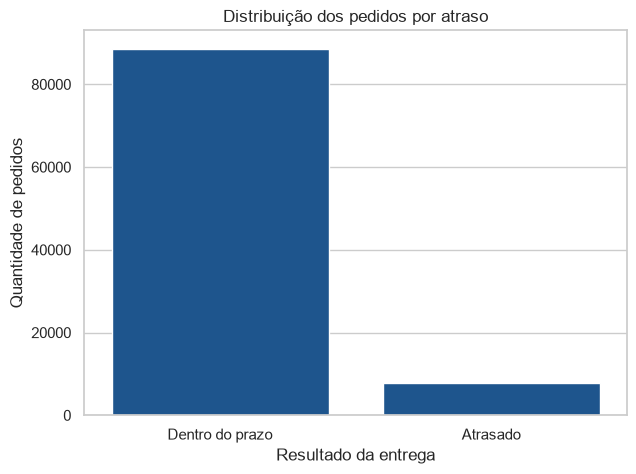

In [9]:
late_counts = orders_analysis["is_late"].value_counts().sort_index()
late_rate = orders_analysis["is_late"].mean()
baseline_accuracy = (orders_analysis["is_late"] == 0).mean()

print(f"Total de pedidos: {len(orders_analysis):,}")
print(f"Pedidos dentro do prazo: {late_counts.get(0, 0):,}")
print(f"Pedidos atrasados: {late_counts.get(1, 0):,}")
print(f"Taxa de atraso: {late_rate:.2%}")
print(f"Acurácia do modelo que sempre prevê 'não atrasará': {baseline_accuracy:.2%}")

plt.figure(figsize=(7, 5))

sns.barplot(
    x=late_counts.index.map({
        0: "Dentro do prazo",
        1: "Atrasado"
    }),
    y=late_counts.values
)

plt.title("Distribuição dos pedidos por atraso")
plt.xlabel("Resultado da entrega")
plt.ylabel("Quantidade de pedidos")
plt.show()

**Conclusão da pergunta 1:** escreva aqui o que os dados mostraram.

- Taxa de atraso: `8,1%`
- A hipótese foi apoiada? `Sim. Os atrasos são minoritários e existe desbalanceamento entre as classes.`
- Implicação para a modelagem: `a acurácia não deve ser utilizada isoladamente, pois um modelo que sempre previsse “não atrasará” teria alta acurácia mesmo sem identificar os atrasos.`

# Pergunta 2: Pedidos com prazos menores atrasam mais?

**Hipótese:** quando a empresa promete entregar em poucos dias, existe menos
margem para problemas logísticos e o pedido pode apresentar maior risco de atraso.


,promised_days_group,total_pedidos,pedidos_atrasados,taxa_atraso
0,0–5 dias,773,287,37.128072
1,5–10 dias,3904,465,11.910861
2,10–15 dias,10833,635,5.861719
3,15–20 dias,17656,1601,9.067739
4,20–25 dias,26082,2359,9.044552
5,25–30 dias,18786,1485,7.904823
6,30+ dias,18416,991,5.381190


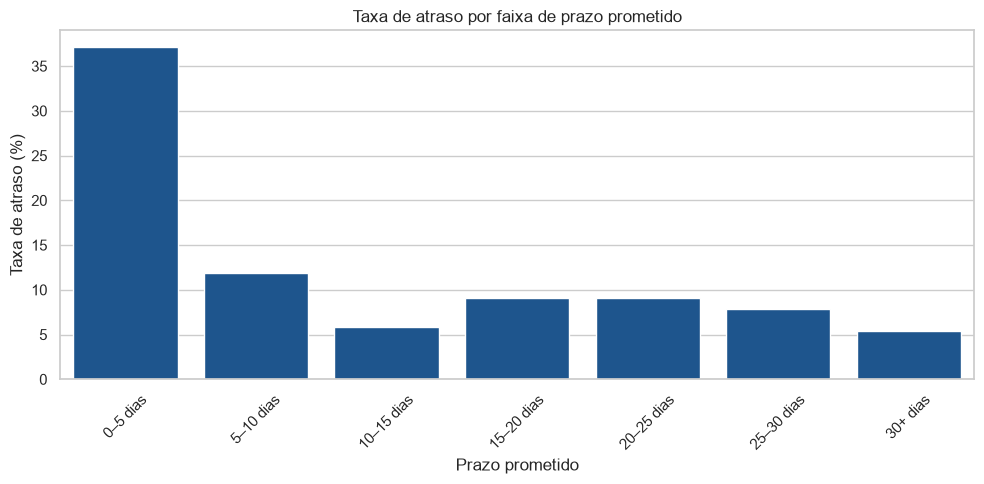

In [10]:
bins = [0, 5, 10, 15, 20, 25, 30, np.inf]

labels = [
    "0–5 dias",
    "5–10 dias",
    "10–15 dias",
    "15–20 dias",
    "20–25 dias",
    "25–30 dias",
    "30+ dias"
]

orders_analysis["promised_days_group"] = pd.cut(
    orders_analysis["promised_days"],
    bins=bins,
    labels=labels,
    right=False
)

deadline_analysis = (
    orders_analysis
    .groupby("promised_days_group", observed=False)
    .agg(
        total_pedidos=("is_late", "size"),
        pedidos_atrasados=("is_late", "sum"),
        taxa_atraso=("is_late", "mean")
    )
    .reset_index()
)

deadline_analysis["taxa_atraso"] *= 100

display(deadline_analysis)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=deadline_analysis,
    x="promised_days_group",
    y="taxa_atraso",
    ax=ax1
)

ax1.set_title("Taxa de atraso por faixa de prazo prometido")
ax1.set_xlabel("Prazo prometido")
ax1.set_ylabel("Taxa de atraso (%)")
ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Conclusão da pergunta 2:** a taxa muda de forma consistente entre as faixas? Há faixas com poucas observações?

A taxa de atraso apresenta diferenças entre as faixas de prazo, indicando que o prazo prometido pode estar associado ao risco. Entretanto, algumas faixas possuem poucas observações e podem apresentar taxas instáveis. Portanto, a relação deve ser analisada em conjunto com outras características logísticas.

# Pergunta 3: Pedidos maiores ou mais complexos atrasam mais?

**Hipótese:** pedidos com mais itens ou vendedores apresentam maior complexidade logística e maior risco.

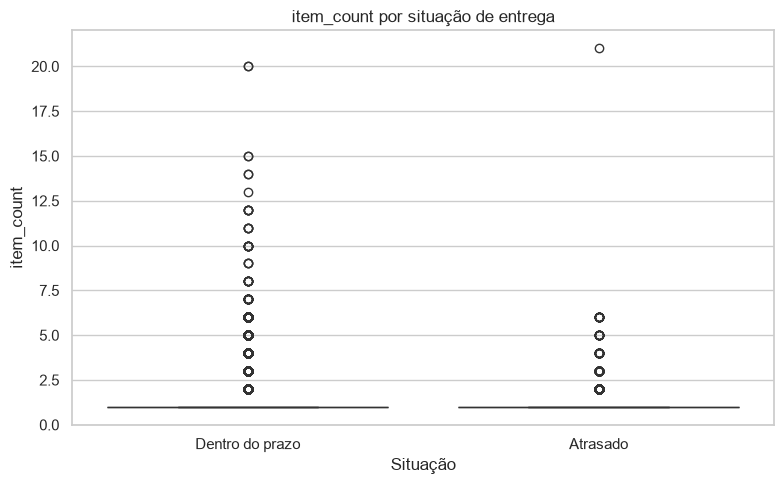

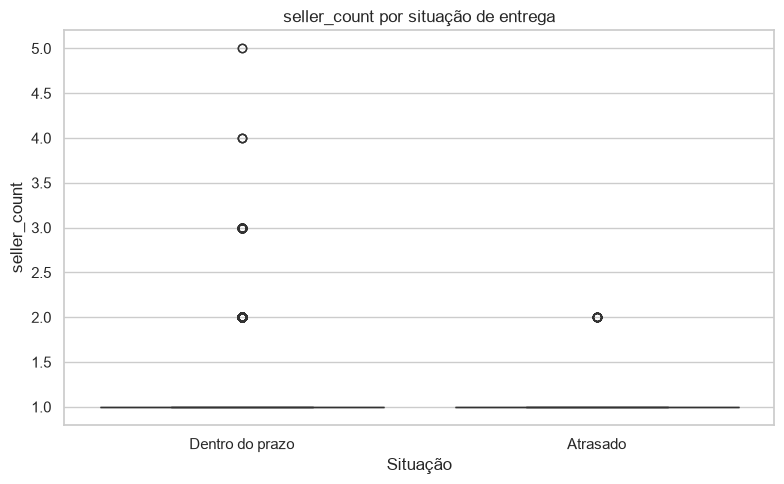

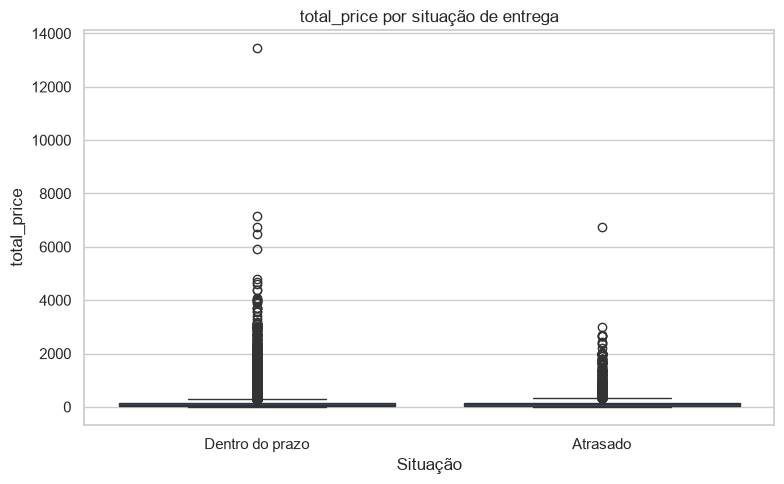

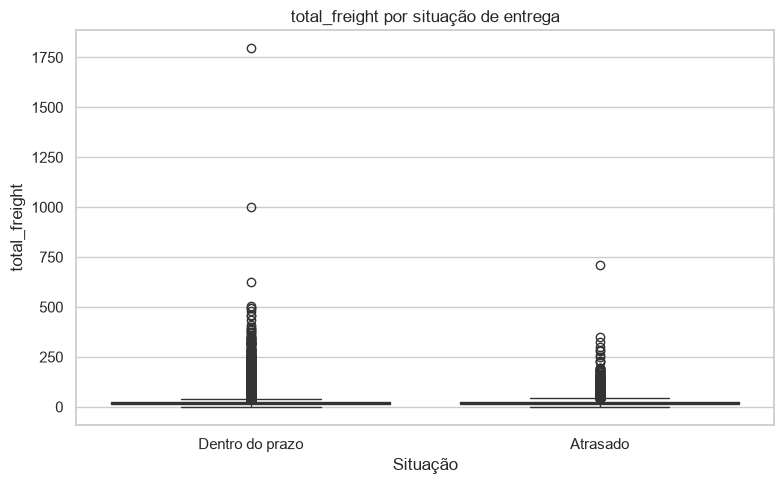

,item_count,seller_count,total_price,total_freight
status,,,,
Atrasado,1.0,1.0,89.9,18.055
Dentro do prazo,1.0,1.0,85.5,17.070


In [11]:
complexity_columns = [
    "item_count",
    "seller_count",
    "total_price",
    "total_freight"
]

complexity_data = orders_analysis[
    ["is_late"] + complexity_columns
].copy()

complexity_data["status"] = complexity_data["is_late"].map({
    0: "Dentro do prazo",
    1: "Atrasado"
})

for column in complexity_columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=complexity_data,
        x="status",
        y=column
    )

    plt.title(f"{column} por situação de entrega")
    plt.xlabel("Situação")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

complexity_summary = (
    complexity_data
    .groupby("status")[complexity_columns]
    .median()
)

display(complexity_summary)

**Conclusão da pergunta 3:** diferenças nas medianas parecem operacionalmente relevantes? Os boxplots mostram muita sobreposição?

As diferenças entre pedidos atrasados e não atrasados não parecem ser fortes. Os boxplots apresentam bastante sobreposição entre os grupos, indicando que quantidade de itens, vendedores, preço e frete não explicam isoladamente o atraso. Essas variáveis podem contribuir para o modelo quando combinadas com outras features.


# Pergunta 4: O risco varia geograficamente?

**Hipótese:** alguns estados apresentam maior risco devido à distância ou à infraestrutura logística.

Para evitar conclusões instáveis, mostraremos apenas estados com pelo menos 100 pedidos no recorte.

,customer_state,total_pedidos,pedidos_atrasados,taxa_atraso
1,AL,397,95,23.929471
9,MA,716,141,19.692737
16,PI,476,76,15.966387
5,CE,1278,196,15.336463
24,SE,335,51,15.223881
4,BA,3256,457,14.035627
18,RJ,12348,1664,13.475867
26,TO,274,35,12.773723
13,PA,946,117,12.367865
7,ES,1995,244,12.230576


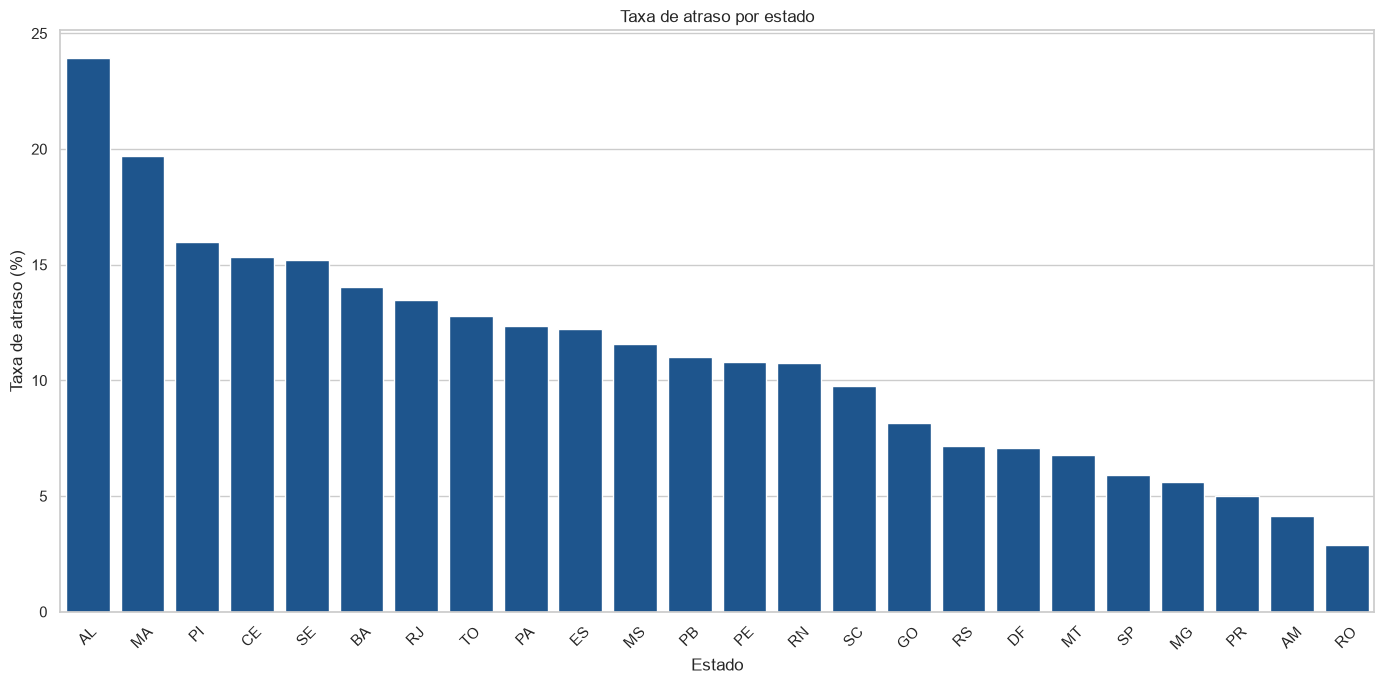

In [12]:
state_analysis = (
    orders_analysis
    .groupby("customer_state")
    .agg(
        total_pedidos=("is_late", "size"),
        pedidos_atrasados=("is_late", "sum"),
        taxa_atraso=("is_late", "mean")
    )
    .reset_index()
)

state_analysis["taxa_atraso"] *= 100

state_analysis = state_analysis[
    state_analysis["total_pedidos"] >= 100
].sort_values(
    "taxa_atraso",
    ascending=False
)

display(state_analysis)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=state_analysis,
    x="customer_state",
    y="taxa_atraso"
)

plt.title("Taxa de atraso por estado")
plt.xlabel("Estado")
plt.ylabel("Taxa de atraso (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Conclusão da pergunta 4:** localização pode ser útil, mas “estado” talvez esteja representando outros fatores não observados. Que fatores seriam esses?

Sim, o risco varia geograficamente. Alguns estados apresentam taxas de atraso superiores à média, indicando que a localização pode ser uma feature útil. Porém, o estado pode estar representando fatores não observados, como distância, infraestrutura logística, transportadoras, hubs, rotas e localização dos vendedores.

# Pergunta 5: O momento da compra está associado ao atraso?

**Hipótese:** determinados meses enfrentam maior pressão logística e apresentam maior taxa de atraso.

,purchase_month,total_pedidos,pedidos_atrasados,taxa_atraso
0,1,7817,487,6.230012
1,2,8196,1101,13.433382
2,3,9549,1638,17.153629
3,4,9101,542,5.955390
4,5,10294,684,6.644647
5,6,9231,204,2.209945
6,7,10028,409,4.078580
7,8,10544,799,7.577769
8,9,4151,217,5.227656
9,10,4743,240,5.060089


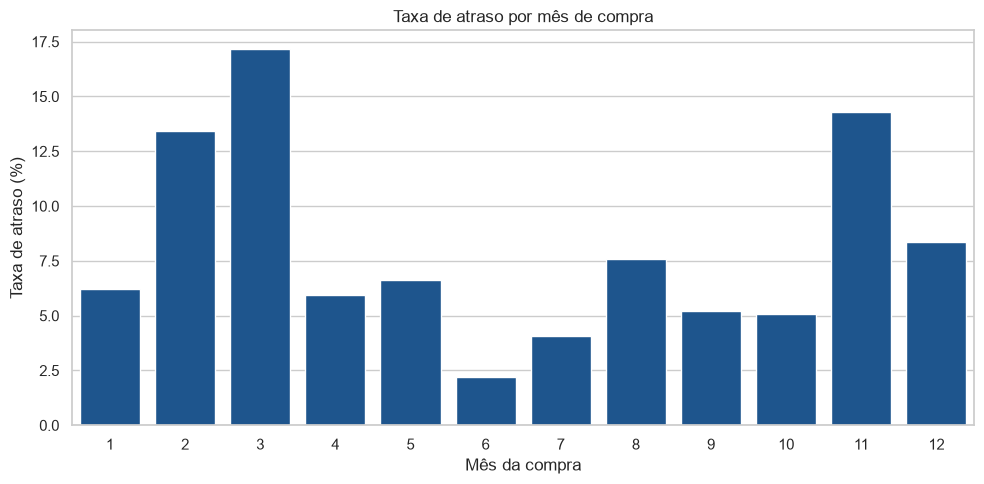

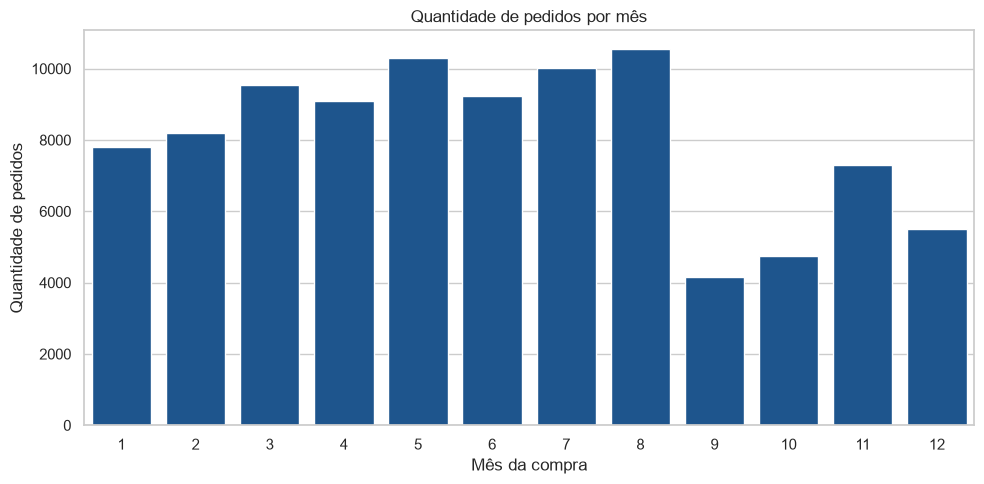

In [13]:
monthly_analysis = (
    orders_analysis
    .groupby("purchase_month")
    .agg(
        total_pedidos=("is_late", "size"),
        pedidos_atrasados=("is_late", "sum"),
        taxa_atraso=("is_late", "mean")
    )
    .reset_index()
)

monthly_analysis["taxa_atraso"] *= 100

display(monthly_analysis)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=monthly_analysis,
    x="purchase_month",
    y="taxa_atraso",
    ax=ax1
)

ax1.set_title("Taxa de atraso por mês de compra")
ax1.set_xlabel("Mês da compra")
ax1.set_ylabel("Taxa de atraso (%)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_analysis,
    x="purchase_month",
    y="total_pedidos"
)

plt.title("Quantidade de pedidos por mês")
plt.xlabel("Mês da compra")
plt.ylabel("Quantidade de pedidos")

plt.tight_layout()
plt.show()

**Conclusão da pergunta 5:** há indícios de sazonalidade? Compare também a quantidade de pedidos por mês antes de concluir.

Há indícios de variação da taxa de atraso entre os meses, indicando possível sazonalidade. Entretanto, é necessário considerar também a quantidade de pedidos de cada mês, pois um maior número absoluto de atrasos pode simplesmente ser consequência de maior volume de pedidos. O mês da compra pode ser uma feature útil, mas deve ser interpretado junto com outros fatores.

